# Preprocessing Dataset UCI Daily and Sports Activities
### Kelompok 21 - Analisis Big Data ITERA 2026

**Alur preprocessing:**
1. Download & ekstrak dataset
2. Load semua file (aktivitas yang dipilih, 8 orang)
3. Filter aktivitas yang relevan untuk SDG 3
4. Feature extraction per segmen
5. Split train/test per orang (bukan per baris)
6. Modeling dengan Random Forest
7. Evaluasi (F1-Score)

## 1. Download & Ekstrak Dataset

In [ ]:
!curl -L "https://archive.ics.uci.edu/static/public/256/daily+and+sports+activities.zip" -o activities.zip
!unzip -q activities.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  162M    0  162M    0     0  23.7M      0 --:--:--  0:00:06 --:--:-- 24.9M
replace data/a01/p1/s01.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


## 2. Definisi Kolom, Aktivitas, dan Konfigurasi

In [ ]:
import pandas as pd
import numpy as np
import os
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [ ]:
# ============================================================
# KONFIGURASI UTAMA
# ============================================================

# 45 kolom sensor (5 bagian tubuh x 9 sensor)
SENSOR_COLUMNS = [
    'T_xacc',  'T_yacc',  'T_zacc',  'T_xgyro',  'T_ygyro',  'T_zgyro',  'T_xmag',  'T_ymag',  'T_zmag',
    'RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro', 'RA_xmag', 'RA_ymag', 'RA_zmag',
    'LA_xacc', 'LA_yacc', 'LA_zacc', 'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag',
    'RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro', 'RL_xmag', 'RL_ymag', 'RL_zmag',
    'LL_xacc', 'LL_yacc', 'LL_zacc', 'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag'
]

# ============================================================
# FILTER AKTIVITAS
# Kita hanya pakai aktivitas yang relevan untuk SDG 3
# (pemantauan gaya hidup sedentary vs aktif)
# Dihapus: A13-A19 (aktivitas gym spesifik & olahraga ekstrem)
# ============================================================
SELECTED_ACTIVITIES = {
    'a01': 'sitting',
    'a02': 'standing',
    'a03': 'lying_back',
    'a04': 'lying_right',
    'a05': 'ascending_stairs',
    'a06': 'descending_stairs',
    'a07': 'standing_elevator',
    'a08': 'moving_elevator',
    'a10': 'walking_treadmill',
    'a12': 'running_treadmill'


}

# Aktivitas yang dihapus (tidak relevan untuk SDG 3)
REMOVED_ACTIVITIES = {
    'a09': 'walking',
    'a11': 'walking_football',
    'a13': 'stepper',
    'a14': 'cross_trainer',
    'a15': 'cycling_horizontal',
    'a16': 'cycling_vertical',
    'a17': 'rowing',
    'a18': 'jumping',
    'a19': 'playing_basketball'
}

# Kategori aktivitas untuk analisis sedentary lifestyle
ACTIVITY_CATEGORIES = {
    'sitting':                    'sedentary',
    'standing':                   'sedentary',
    'lying_back':                 'sedentary',
    'lying_right':                'sedentary',
    'standing_elevator':          'sedentary',
    'walking_treadmill':          'light_activity',
    'ascending_stairs':           'light_activity',
    'descending_stairs':          'light_activity',
    'moving_elevator':            'light_activity',
    'walking':                    'light_activity',
    'running_treadmill':          'intense_activity'
}

# Konfigurasi split
TRAIN_PERSONS = [1, 2, 3, 4, 5, 6]  # 6 orang untuk training
TEST_PERSONS  = [7, 8]               # 2 orang untuk testing

DATA_PATH = '/content/data'

print(f'Aktivitas yang digunakan : {len(SELECTED_ACTIVITIES)}')
print(f'Aktivitas yang dihapus   : {len(REMOVED_ACTIVITIES)}')
print(f'Orang untuk training     : {TRAIN_PERSONS}')
print(f'Orang untuk testing      : {TEST_PERSONS}')


Aktivitas yang digunakan : 10
Aktivitas yang dihapus   : 9
Orang untuk training     : [1, 2, 3, 4, 5, 6]
Orang untuk testing      : [7, 8]


## 3. Load Semua Data

In [ ]:
def load_all_data(data_path, selected_activities, sensor_columns):
    """
    Load semua file dari dataset.
    Struktur folder: data/a{activity}/p{person}/s{segment}.txt
    """
    all_records = []

    for act_id, act_label in selected_activities.items():
        act_path = os.path.join(data_path, act_id)

        if not os.path.exists(act_path):
            print(f'WARNING: Folder tidak ditemukan: {act_path}')
            continue

        for p_num in range(1, 9):  # p1 sampai p8
            person_path = os.path.join(act_path, f'p{p_num}')

            if not os.path.exists(person_path):
                continue

            for s_num in range(1, 61):  # s01 sampai s60
                file_path = os.path.join(person_path, f's{s_num:02d}.txt')

                if not os.path.exists(file_path):
                    continue

                try:
                    df = pd.read_csv(file_path, header=None, names=sensor_columns)
                    df['activity_id']    = act_id
                    df['activity_label'] = act_label
                    df['person_id']      = p_num
                    df['segment_id']     = s_num
                    df['timestep']       = range(len(df))
                    all_records.append(df)
                except Exception as e:
                    print(f'ERROR loading {file_path}: {e}')

    if not all_records:
        raise ValueError('Tidak ada data yang berhasil diload!')

    result = pd.concat(all_records, ignore_index=True)
    return result


print('Mulai loading data...')
raw_df = load_all_data(DATA_PATH, SELECTED_ACTIVITIES, SENSOR_COLUMNS)

print(f'\nTotal baris (raw)  : {len(raw_df):,}')
print(f'Total kolom        : {len(raw_df.columns)}')
print(f'Aktivitas unik     : {raw_df["activity_label"].nunique()}')
print(f'Person unik        : {raw_df["person_id"].nunique()}')
print(f'Segmen per akt/org : {raw_df["segment_id"].max()}')
print(f'\nDistribusi aktivitas:')
print(raw_df.groupby('activity_label')['segment_id'].count().rename('total_timesteps'))

Mulai loading data...

Total baris (raw)  : 600,000
Total kolom        : 50
Aktivitas unik     : 10
Person unik        : 8
Segmen per akt/org : 60

Distribusi aktivitas:
activity_label
ascending_stairs     60000
descending_stairs    60000
lying_back           60000
lying_right          60000
moving_elevator      60000
running_treadmill    60000
sitting              60000
standing             60000
standing_elevator    60000
walking_treadmill    60000
Name: total_timesteps, dtype: int64


## 4. Eksplorasi Data (EDA)

In [ ]:
# Cek missing values
print('=== Missing Values ===')
missing = raw_df[SENSOR_COLUMNS].isnull().sum()
print(f'Total missing values: {missing.sum()}')
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print('Tidak ada missing values.')

# Cek duplikasi
print(f'\n=== Duplikasi ===')
print(f'Jumlah baris duplikat: {raw_df.duplicated().sum()}')

# Statistik dasar
print('\n=== Statistik Dasar Sensor ===')
print(raw_df[SENSOR_COLUMNS].describe().round(4))

=== Missing Values ===
Total missing values: 0
Tidak ada missing values.

=== Duplikasi ===
Jumlah baris duplikat: 0

=== Statistik Dasar Sensor ===
            T_xacc       T_yacc       T_zacc      T_xgyro      T_ygyro  \
count  600000.0000  600000.0000  600000.0000  600000.0000  600000.0000   
mean        6.9754      -1.2681       3.2901      -0.0023       0.0134   
std         5.7537       2.9228       3.5603       0.7453       0.6766   
min        -9.9357     -35.8990     -41.7630     -16.7160     -15.6220   
25%         4.3991      -1.7566       1.4979      -0.0347      -0.0164   
50%         8.6966      -0.4850       3.1134       0.0004       0.0178   
75%         9.4867       0.1836       4.8060       0.0365       0.0460   
max        93.6940      41.0130     120.5300      18.9270       9.0949   

           T_zgyro       T_xmag       T_ymag       T_zmag      RA_xacc  ...  \
count  600000.0000  600000.0000  600000.0000  600000.0000  600000.0000  ...   
mean       -0.0031      -0

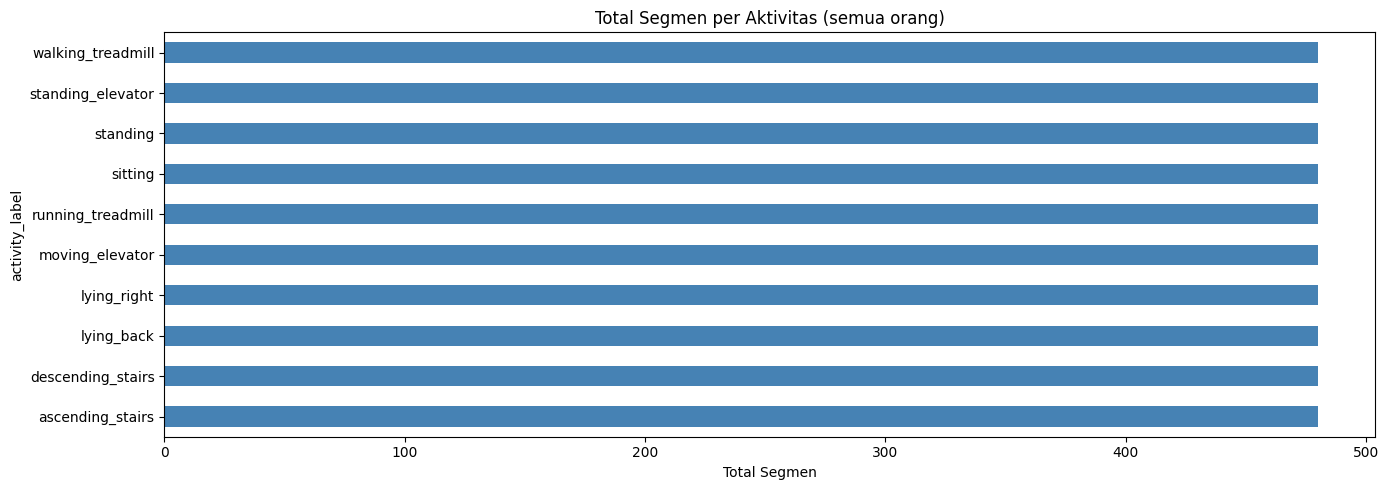

Data sudah seimbang - setiap aktivitas memiliki 60 segmen x 8 orang = 480 segmen


In [ ]:
# Distribusi per aktivitas
activity_counts = raw_df.groupby(['activity_label', 'person_id'])['segment_id'].nunique().reset_index()
activity_counts.columns = ['activity_label', 'person_id', 'n_segments']

plt.figure(figsize=(14, 5))
summary = activity_counts.groupby('activity_label')['n_segments'].sum().sort_values()
summary.plot(kind='barh', color='steelblue')
plt.title('Total Segmen per Aktivitas (semua orang)')
plt.xlabel('Total Segmen')
plt.tight_layout()
plt.show()
print('Data sudah seimbang - setiap aktivitas memiliki 60 segmen x 8 orang = 480 segmen')

In [ ]:
# ============================================================
# TAMBAHAN: Magnitude per sensor per bagian tubuh
# ============================================================

body_parts = {
    'T':  ('T_xacc',  'T_yacc',  'T_zacc',  'T_xgyro',  'T_ygyro',  'T_zgyro',  'T_xmag',  'T_ymag',  'T_zmag'),
    'RA': ('RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro', 'RA_xmag', 'RA_ymag', 'RA_zmag'),
    'LA': ('LA_xacc', 'LA_yacc', 'LA_zacc', 'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag'),
    'RL': ('RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro', 'RL_xmag', 'RL_ymag', 'RL_zmag'),
    'LL': ('LL_xacc', 'LL_yacc', 'LL_zacc', 'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag'),
}

MAG_COLUMNS = []

for part, cols in body_parts.items():
    xacc, yacc, zacc, xgyro, ygyro, zgyro, xmag, ymag, zmag = cols

    raw_df[f'{part}_acc_mag']  = np.sqrt(raw_df[xacc]**2  + raw_df[yacc]**2  + raw_df[zacc]**2)
    raw_df[f'{part}_gyro_mag'] = np.sqrt(raw_df[xgyro]**2 + raw_df[ygyro]**2 + raw_df[zgyro]**2)
    raw_df[f'{part}_mag_mag']  = np.sqrt(raw_df[xmag]**2  + raw_df[ymag]**2  + raw_df[zmag]**2)

    MAG_COLUMNS += [f'{part}_acc_mag', f'{part}_gyro_mag', f'{part}_mag_mag']

print(f'Kolom magnitude ditambahkan: {len(MAG_COLUMNS)}')
print(MAG_COLUMNS)

Kolom magnitude ditambahkan: 15
['T_acc_mag', 'T_gyro_mag', 'T_mag_mag', 'RA_acc_mag', 'RA_gyro_mag', 'RA_mag_mag', 'LA_acc_mag', 'LA_gyro_mag', 'LA_mag_mag', 'RL_acc_mag', 'RL_gyro_mag', 'RL_mag_mag', 'LL_acc_mag', 'LL_gyro_mag', 'LL_mag_mag']


## 5. Feature Extraction per Segmen

Karena setiap segmen = 125 timestep (5 detik x 25 Hz),
kita ekstrak fitur statistik per segmen untuk setiap sensor.
Ini adalah pendekatan standar untuk HAR dengan ML klasik.

In [ ]:
## 5. Feature Extraction per Segmen

# Karena setiap segmen = 125 timestep (5 detik x 25 Hz), ekstrak fitur statistik per segmen untuk setiap sensor.

def extract_features_per_segment(df, sensor_columns):
    """
    Ekstrak fitur statistik per segmen dari setiap sensor.
    Output: 1 baris per segmen dengan fitur mean, std, min, max, skew, kurtosis
    """
    group_cols = ['activity_id', 'activity_label', 'person_id', 'segment_id']

    feature_dfs = []

    grouped = df.groupby(group_cols)

    for name, group in grouped:
        feat = {}
        feat['activity_id']    = name[0]
        feat['activity_label'] = name[1]
        feat['person_id']      = name[2]
        feat['segment_id']     = name[3]

        sensor_data = group[sensor_columns]

        for col in sensor_columns:
            series = sensor_data[col]
            feat[f'{col}_mean']     = series.mean()
            feat[f'{col}_std']      = series.std()
            feat[f'{col}_min']      = series.min()
            feat[f'{col}_max']      = series.max()
            feat[f'{col}_skew']     = series.skew()
            feat[f'{col}_kurtosis'] = series.kurtosis()

        feature_dfs.append(feat)

    return pd.DataFrame(feature_dfs)


# Gabungkan kolom sensor asli + magnitude
ALL_COLUMNS = SENSOR_COLUMNS + MAG_COLUMNS

feature_df = extract_features_per_segment(raw_df, ALL_COLUMNS)

print('Mulai feature extraction...')
print('(Proses ini memerlukan beberapa menit)')

feature_df = extract_features_per_segment(raw_df, ALL_COLUMNS)

n_feature_cols = len([c for c in feature_df.columns if c not in ['activity_id', 'activity_label', 'person_id', 'segment_id']])
print(f'\nHasil feature extraction:')
print(f'Total segmen (baris) : {len(feature_df):,}')
print(f'Total fitur          : {n_feature_cols}')
print(f'Total fitur: {n_feature_cols}')
print(f'\nSample 3 baris pertama:')
print(feature_df.head(3))

Mulai feature extraction...
(Proses ini memerlukan beberapa menit)

Hasil feature extraction:
Total segmen (baris) : 4,800
Total fitur          : 360
Total fitur: 360

Sample 3 baris pertama:
  activity_id activity_label  person_id  segment_id  T_xacc_mean  T_xacc_std  \
0         a01        sitting          1           1     7.975714    0.119981   
1         a01        sitting          1           2     7.978250    0.086896   
2         a01        sitting          1           3     7.970894    0.055603   

   T_xacc_min  T_xacc_max  T_xacc_skew  T_xacc_kurtosis  ...  LL_gyro_mag_min  \
0      7.6823      8.1605    -0.023603        -1.011485  ...         0.002558   
1      7.8472      8.1763     0.559149        -0.916460  ...         0.002901   
2      7.8470      8.0860     0.101763        -0.905424  ...         0.001604   

   LL_gyro_mag_max  LL_gyro_mag_skew  LL_gyro_mag_kurtosis  LL_mag_mag_mean  \
0         0.025691          0.153919             -0.503035         0.800677   
1   

## 6. Tambahkan Kategori Aktivitas & Normalisasi

In [ ]:
from sklearn.preprocessing import StandardScaler

# Tambahkan kategori aktivitas (sedentary / light / moderate / intense)

feature_df['activity_category'] = feature_df['activity_label'].map(ACTIVITY_CATEGORIES)

print('Distribusi kategori aktivitas:')
print(feature_df['activity_category'].value_counts())
print()

# Kolom fitur saja (exclude metadata)
meta_cols    = ['activity_id', 'activity_label', 'activity_category', 'person_id', 'segment_id']
feature_cols = [c for c in feature_df.columns if c not in meta_cols]

print(f'Total kolom fitur: {len(feature_cols)}')
print('Normalisasi akan dilakukan setelah split untuk menghindari data leakage.')

Distribusi kategori aktivitas:
activity_category
sedentary           2400
light_activity      1920
intense_activity     480
Name: count, dtype: int64

Total kolom fitur: 360
Normalisasi akan dilakukan setelah split untuk menghindari data leakage.


In [ ]:
#Cross Validation Leave-One-Person-Out (LOPO) validation untuk estimasi akurasi yang lebih robust

from sklearn.model_selection import cross_val_score, LeaveOneGroupOut

logo = LeaveOneGroupOut()
groups = feature_df['person_id'].values
X_all = feature_df[feature_cols].values
y_all = feature_df['activity_label'].values

# Normalisasi per fold dilakukan di dalam pipeline
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=42,
                                    n_jobs=-1, class_weight='balanced'))
])

scores = cross_val_score(pipeline, X_all, y_all,
                          cv=logo, groups=groups,
                          scoring='f1_macro')
print(f'LOPO F1-macro: {scores.mean():.4f} ± {scores.std():.4f}')

LOPO F1-macro: 0.9343 ± 0.0730


## 7. Split Train/Test per Orang

**Penting:** Split dilakukan per orang, bukan per baris.
Ini mencegah data leakage dan membuat model bisa generalisasi ke orang baru.
- Training: orang 1-6 (75%)
- Testing : orang 7-8 (25%)

In [ ]:
# Split berdasarkan person_id
train_df = feature_df[feature_df['person_id'].isin(TRAIN_PERSONS)].copy()
test_df  = feature_df[feature_df['person_id'].isin(TEST_PERSONS)].copy()

X_train = train_df[feature_cols].values
y_train = train_df['activity_label'].values

X_test  = test_df[feature_cols].values
y_test  = test_df['activity_label'].values

# Normalisasi dilakukan SETELAH split
# scaler hanya fit di training set, lalu transform di test set
# Tujuan: menghindari data leakage dari distribusi test set
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit + transform di train
X_test  = scaler.transform(X_test)       # transform saja di test

print(f'Training set : {X_train.shape[0]:,} segmen dari orang {TRAIN_PERSONS}')
print(f'Testing set  : {X_test.shape[0]:,} segmen dari orang {TEST_PERSONS}')
print(f'Total fitur  : {X_train.shape[1]}')
print(f'\nDistribusi kelas di training set:')
print(pd.Series(y_train).value_counts().sort_index())
print(f'\nDistribusi kelas di testing set:')
print(pd.Series(y_test).value_counts().sort_index())

Training set : 3,600 segmen dari orang [1, 2, 3, 4, 5, 6]
Testing set  : 1,200 segmen dari orang [7, 8]
Total fitur  : 360

Distribusi kelas di training set:
ascending_stairs     360
descending_stairs    360
lying_back           360
lying_right          360
moving_elevator      360
running_treadmill    360
sitting              360
standing             360
standing_elevator    360
walking_treadmill    360
Name: count, dtype: int64

Distribusi kelas di testing set:
ascending_stairs     120
descending_stairs    120
lying_back           120
lying_right          120
moving_elevator      120
running_treadmill    120
sitting              120
standing             120
standing_elevator    120
walking_treadmill    120
Name: count, dtype: int64


## 8. Modeling dengan Random Forest

In [ ]:
print('Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
print('Training selesai!')

# Prediksi
y_pred = rf_model.predict(X_test)

# Evaluasi
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f'\n=== HASIL EVALUASI ===')
print(f'F1-Score (macro)    : {f1_macro:.4f} ({f1_macro*100:.2f}%)')
print(f'F1-Score (weighted) : {f1_weighted:.4f} ({f1_weighted*100:.2f}%)')
print(f'\nTarget proposal     : >= 90%')
print(f'Status              : {"TERCAPAI" if f1_macro >= 0.9 else "BELUM TERCAPAI"}')

print(f'\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred))

Training Random Forest...
Training selesai!

=== HASIL EVALUASI ===
F1-Score (macro)    : 0.8576 (85.76%)
F1-Score (weighted) : 0.8576 (85.76%)

Target proposal     : >= 90%
Status              : BELUM TERCAPAI

=== CLASSIFICATION REPORT ===
                   precision    recall  f1-score   support

 ascending_stairs       1.00      1.00      1.00       120
descending_stairs       1.00      0.99      1.00       120
       lying_back       1.00      1.00      1.00       120
      lying_right       1.00      1.00      1.00       120
  moving_elevator       0.72      0.85      0.78       120
running_treadmill       1.00      1.00      1.00       120
          sitting       1.00      1.00      1.00       120
         standing       0.68      0.14      0.23       120
standing_elevator       0.46      0.74      0.57       120
walking_treadmill       1.00      1.00      1.00       120

         accuracy                           0.87      1200
        macro avg       0.89      0.87      0.86

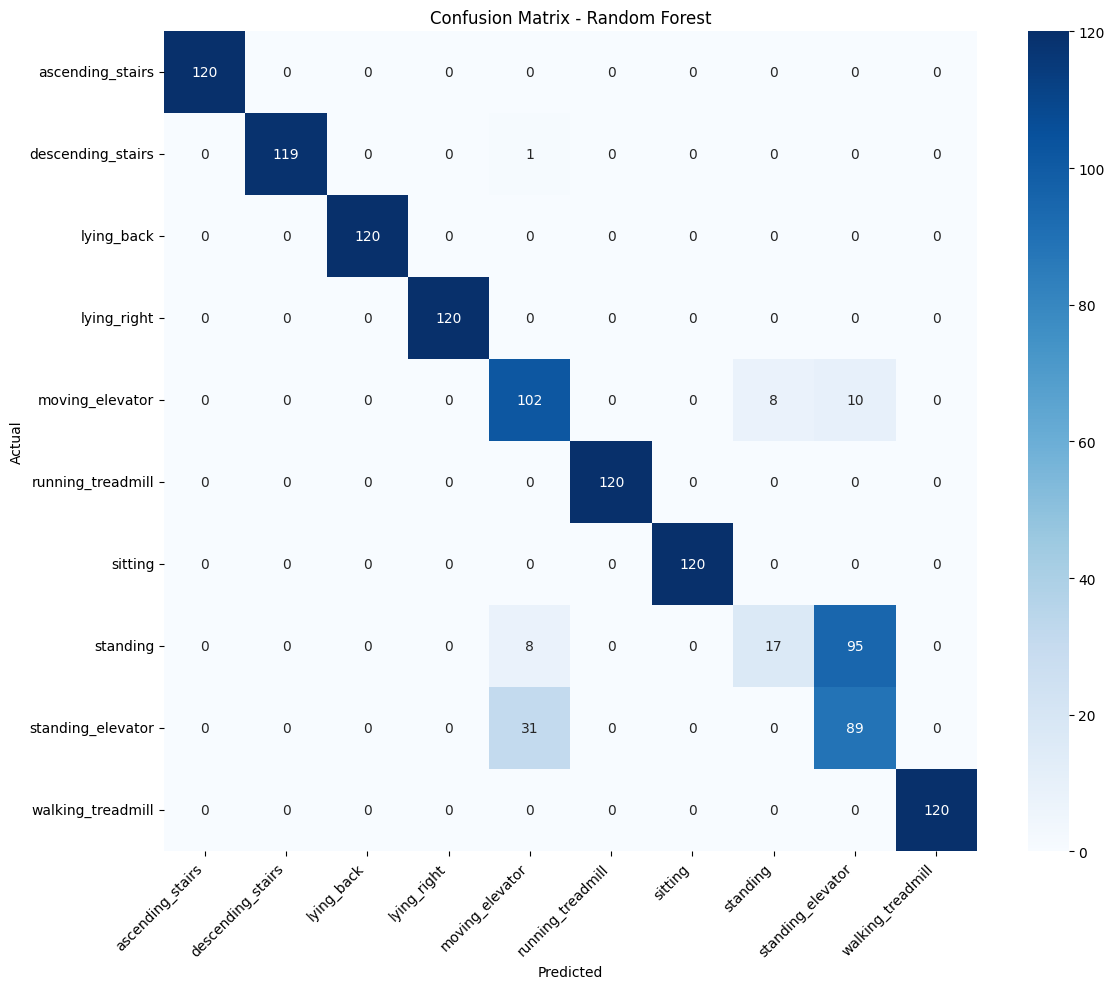

In [ ]:
# Confusion Matrix
labels = sorted(list(set(y_test)))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

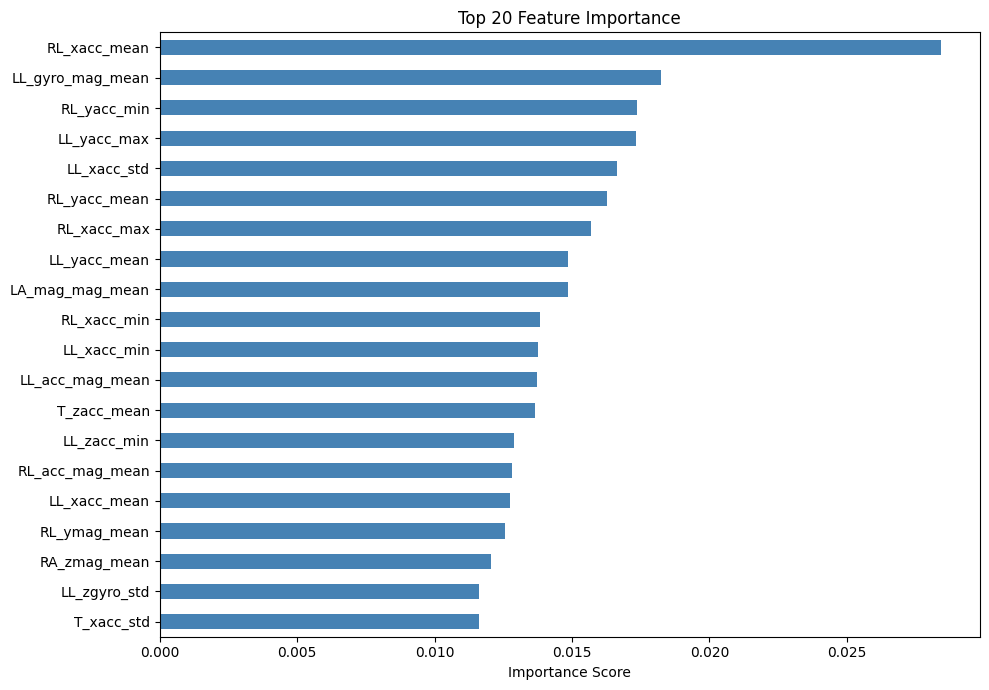

Top 10 fitur paling penting:
RL_xacc_mean        0.028427
LL_gyro_mag_mean    0.018225
RL_yacc_min         0.017366
LL_yacc_max         0.017320
LL_xacc_std         0.016624
RL_yacc_mean        0.016259
RL_xacc_max         0.015707
LL_yacc_mean        0.014840
LA_mag_mag_mean     0.014840
RL_xacc_min         0.013841
dtype: float64


In [ ]:
# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
top_20 = importances.nlargest(20)

plt.figure(figsize=(10, 7))
top_20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 fitur paling penting:')
print(top_20.head(10))

## 9. Simpan Dataset Hasil Preprocessing

In [ ]:
# Simpan raw dataset (sebelum feature extraction) ke CSV
raw_output_path = '/content/raw_dataset.csv'
raw_df.to_csv(raw_output_path, index=False)
print(f'Raw dataset disimpan ke: {raw_output_path}')
print(f'Ukuran file: {os.path.getsize(raw_output_path) / 1024 / 1024:.2f} MB')

# Simpan feature dataset
feature_output_path = '/content/feature_dataset.csv'
feature_df.to_csv(feature_output_path, index=False)
print(f'\nFeature dataset disimpan ke: {feature_output_path}')
print(f'Ukuran file: {os.path.getsize(feature_output_path) / 1024 / 1024:.2f} MB')

# Simpan train/test split
train_df.to_csv('/content/train_set.csv', index=False)
test_df.to_csv('/content/test_set.csv', index=False)
print(f'\nTrain set disimpan ke: /content/train_set.csv')
print(f'Test set disimpan ke : /content/test_set.csv')

Raw dataset disimpan ke: /content/raw_dataset.csv
Ukuran file: 389.94 MB

Feature dataset disimpan ke: /content/feature_dataset.csv
Ukuran file: 27.19 MB

Train set disimpan ke: /content/train_set.csv
Test set disimpan ke : /content/test_set.csv


## 10. Ringkasan Hasil

In [ ]:
print('=' * 55)
print('RINGKASAN PREPROCESSING & MODELING')
print('=' * 55)
print(f'Dataset    : UCI Daily and Sports Activities')
print(f'Aktivitas  : {len(SELECTED_ACTIVITIES)} dari 19 (dihapus {len(REMOVED_ACTIVITIES)} gym spesifik)')
print(f'Subjek     : 8 orang')
print(f'Segmen     : 60 per aktivitas per orang')
print(f'Total seg  : {len(feature_df):,}')
print(f'Fitur      : {len(feature_cols)} (45 sensor x 6 statistik)')
print(f'Split      : p1-p6 train, p7-p8 test (per orang)')
print(f'Model      : Random Forest (n_estimators=300)')
print(f'F1-Score   : {f1_macro*100:.2f}% (target >= 90%)')
print('=' * 55)

RINGKASAN PREPROCESSING & MODELING
Dataset    : UCI Daily and Sports Activities
Aktivitas  : 10 dari 19 (dihapus 9 gym spesifik)
Subjek     : 8 orang
Segmen     : 60 per aktivitas per orang
Total seg  : 4,800
Fitur      : 360 (45 sensor x 6 statistik)
Split      : p1-p6 train, p7-p8 test (per orang)
Model      : Random Forest (n_estimators=300)
F1-Score   : 85.76% (target >= 90%)
